Section 1: Data Loading & Exploration

Question 1
Load the dataset smart_home_sensor_data.csv using Pandas. Programmatically inspect its metadata by executing commands to display:

The first 5 structural rows of the dataset.
The dimensional shape (rows and columns count).
The data types of all individual columns alongside their memory usage profiles.

In [62]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

df = pd.read_csv("/Users/dipusardar/DIPU/Programming/Data-Analysis/Project 06/project06.csv")
print(df.head())

          Timestamp       Room_Type  Temperature_C  Humidity_Pct  \
0  2026-01-01 00:00   Server Closet           24.3          38.9   
1  2026-01-02 07:00   Server Closet           24.1          43.2   
2  2026-01-03 14:00         Kitchen           21.5          52.3   
3  2026-01-04 21:00  Master Bedroom           20.0          37.2   
4  2026-01-06 04:00     Living Room           20.9          46.7   

   Power_Consumption_kWh Motion_Detected Device_Status  
0                  0.923              No        Active  
1                  1.385              No       Standby  
2                  0.316             Yes       Standby  
3                  0.188              No       Standby  
4                  0.301             Yes        Active  


Question 1
Load the dataset smart_home_sensor_data.csv using Pandas. Programmatically inspect its metadata by executing commands to display:

The first 5 structural rows of the dataset.
The dimensional shape (rows and columns count).
The data types of all individual columns alongside their memory usage profiles.

In [63]:
print(df.head(5))
print(df.shape)
print(df.dtypes)

          Timestamp       Room_Type  Temperature_C  Humidity_Pct  \
0  2026-01-01 00:00   Server Closet           24.3          38.9   
1  2026-01-02 07:00   Server Closet           24.1          43.2   
2  2026-01-03 14:00         Kitchen           21.5          52.3   
3  2026-01-04 21:00  Master Bedroom           20.0          37.2   
4  2026-01-06 04:00     Living Room           20.9          46.7   

   Power_Consumption_kWh Motion_Detected Device_Status  
0                  0.923              No        Active  
1                  1.385              No       Standby  
2                  0.316             Yes       Standby  
3                  0.188              No       Standby  
4                  0.301             Yes        Active  
(110, 7)
Timestamp                    str
Room_Type                    str
Temperature_C            float64
Humidity_Pct             float64
Power_Consumption_kWh    float64
Motion_Detected              str
Device_Status                str
dtype: ob

Question 2
Determine the integrity of the collected dataset:

Identify which columns contain missing (NaN/Null) parameters.
Calculate the exact count of missing entries for each column.
Deduce the data type of the Timestamp column. Is it optimized for time-series extraction tasks?

In [64]:
print(df.isnull().any())
print('-' * 50)
print(df.isnull().sum())
print('-' * 50)
print(df['Timestamp'].dtype)

Timestamp                False
Room_Type                False
Temperature_C             True
Humidity_Pct              True
Power_Consumption_kWh     True
Motion_Detected          False
Device_Status             True
dtype: bool
--------------------------------------------------
Timestamp                0
Room_Type                0
Temperature_C            7
Humidity_Pct             3
Power_Consumption_kWh    2
Motion_Detected          0
Device_Status            1
dtype: int64
--------------------------------------------------
str


In [65]:
import pandas as pd

# ১. টাইপটিকে স্পষ্ট করে str() দিয়ে টেক্সট বানিয়ে নিন
Timestamp_type = str(df['Timestamp'].dtype)

# ২. এবার টেক্সট হিসেবে 'object' চেক করুন
if Timestamp_type == 'object':
    print("\n[Analysis Warning]: The Timestamp column is currently stored as generic 'object' (string data).")
    print("It is NOT optimized for time-series extraction. We cannot programmatically extract components ")
    print("like hour, day, or month via vectorized operations without explicitly parsing it first.")
else:
    print("\n[Analysis Success]: The Timestamp column is optimized for time-series tasks.")


[Analysis Success]: The Timestamp column is optimized for time-series tasks.


# Section 2: Data Cleaning & Manipulation


Question 3
Address the missing historical logs discovered within the numeric indices:

Impute (fill) the missing values in Temperature_C using the dataset's global median temperature.
Impute the missing values in Humidity_Pct using the dataset's global mean humidity.
Drop any rows where the structural status string parameter Device_Status is missing. Validate your modifications by checking the new shape of your DataFrame.

In [66]:
print(df.columns)
print("_" * 100)

median_Temperature = df['Temperature_C'].median()
df['Temperature_C'] = df['Temperature_C'].fillna(median_Temperature)

print(df['Temperature_C'].isnull().any())


Index(['Timestamp', 'Room_Type', 'Temperature_C', 'Humidity_Pct',
       'Power_Consumption_kWh', 'Motion_Detected', 'Device_Status'],
      dtype='str')
____________________________________________________________________________________________________
False


In [67]:
print(df['Humidity_Pct'].isnull().any())

mean_humidity = df['Humidity_Pct'].mean()
df['Humidity_Pct'] = df['Humidity_Pct'].fillna(mean_humidity)
print(df['Humidity_Pct'].isnull().any())

True
False


In [68]:
#before dropping
print('Before Dropping', df.shape)

df = df.dropna(subset=['Device_Status'])

#After dropping 
print('After Dropping', df.shape)

Before Dropping (110, 7)
After Dropping (109, 7)


Question 4
Convert data values to clear analytical categories:

Convert the Timestamp column from a standard text string to a true Pandas datetime64 object.
Cast the categorical object columns (Room_Type, Motion_Detected, Device_Status) into the memory-optimized category data type to demonstrate industrial memory-management techniques.

In [69]:
print(df.columns)
print('-' * 100)

print("Before\n",df['Timestamp'].dtype)
print('-' * 100)


df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
print('After: ', df['Timestamp'].dtype)

Index(['Timestamp', 'Room_Type', 'Temperature_C', 'Humidity_Pct',
       'Power_Consumption_kWh', 'Motion_Detected', 'Device_Status'],
      dtype='str')
----------------------------------------------------------------------------------------------------
Before
 str
----------------------------------------------------------------------------------------------------
After:  datetime64[us]


In [70]:
cols_to_Convert = ['Room_Type', 'Motion_Detected', 'Device_Status']
df[cols_to_Convert] = df[cols_to_Convert].astype('category')

print(df[cols_to_Convert].dtypes)

Room_Type          category
Motion_Detected    category
Device_Status      category
dtype: object


Question 5
Filter out specific target records for operational diagnostics:

Isolate all observation rows where the Room_Type matches 'Server Closet' and the recorded Temperature_C exceeds 25.0°C.
Sort the resulting subset in descending order based on their Power_Consumption_kWh values to pinpoint periods of peak load.

In [71]:
print(df.columns)
print('_' * 100)

print(df[['Room_Type', 'Temperature_C']])
print('_' * 100)
print('===Now it is filter time===')
filter = df[(df['Room_Type'] == 'Server Closet') & (df['Temperature_C'] > 25.0)]
print(filter.reset_index())



Index(['Timestamp', 'Room_Type', 'Temperature_C', 'Humidity_Pct',
       'Power_Consumption_kWh', 'Motion_Detected', 'Device_Status'],
      dtype='str')
____________________________________________________________________________________________________
          Room_Type  Temperature_C
0     Server Closet           24.3
1     Server Closet           24.1
2           Kitchen           21.5
3    Master Bedroom           20.0
4       Living Room           20.9
..              ...            ...
104         Kitchen           18.6
105         Kitchen           19.2
106         Kitchen           22.5
108   Server Closet           24.1
109     Living Room           19.3

[109 rows x 2 columns]
____________________________________________________________________________________________________
===Now it is filter time===
   index           Timestamp      Room_Type  Temperature_C  Humidity_Pct  \
0      8 2026-01-11 08:00:00  Server Closet           26.4          32.7   
1     20 2026-01-26 

In [72]:
Sorting = filter.sort_values(by='Power_Consumption_kWh', ascending=False)
print(Sorting.reset_index())

   index           Timestamp      Room_Type  Temperature_C  Humidity_Pct  \
0     34 2026-02-13 22:00:00  Server Closet           25.6          42.4   
1     71 2026-04-02 17:00:00  Server Closet           25.3          47.9   
2     54 2026-03-11 18:00:00  Server Closet           25.9          45.3   
3     60 2026-03-19 12:00:00  Server Closet           25.1          43.8   
4     80 2026-04-14 02:00:00  Server Closet           25.6          44.2   
5      8 2026-01-11 08:00:00  Server Closet           26.4          32.7   
6     72                 NaT  Server Closet           25.2          54.9   
7     20 2026-01-26 20:00:00  Server Closet           25.4          47.1   
8     65 2026-03-25 23:00:00  Server Closet           25.6          41.3   
9    102                 NaT  Server Closet           25.9          46.9   

   Power_Consumption_kWh Motion_Detected Device_Status  
0                  1.480              No        Active  
1                  1.411              No       St

# Section 3: Mathematical & Statistical Analysis

Question 6
Leverage NumPy or vector-based Pandas operations to run descriptive environmental audits:

Compute the global maximum, minimum, and variance values for the Temperature_C metrics across the entire home.
Calculate the standard deviation and the 75th percentile (3rd quartile) value for Power_Consumption_kWh.

In [73]:
print('===Maximum===')
print(df['Temperature_C'].max())
print('===Minimum===')
print(df['Temperature_C'].min())
print('===Variance Values===')
print(df['Temperature_C'].var())

===Maximum===
26.4
===Minimum===
17.2
===Variance Values===
5.353246687054029


In [74]:
power_std = df['Power_Consumption_kWh'].std()
power_75th = df['Power_Consumption_kWh'].quantile(0.75)

print(f'Standard Deviation: {power_std}')
print(f'75th Percentile: {power_75th}')


Standard Deviation: 0.6187951364655505
75th Percentile: 1.189


Question 7
Execute categorical data segmentation metrics using aggregation principles:

Group the dataset by Room_Type and isolate the Power_Consumption_kWh column.
Apply aggregations to display the aggregate total (sum) and the relative metric center (mean) for each distinct room type. Which room consumes the highest total energy?

In [79]:
group = df.groupby('Room_Type')['Power_Consumption_kWh'].agg(['sum', 'mean'])
print(group)
print('_' * 60)
print(df.columns)
print('_' * 60)


highest_consumption = group.sort_values(by='sum', ascending=False).head(1)
print(highest_consumption)

                   sum      mean
Room_Type                       
Home Office      3.936  0.196800
Kitchen         28.516  1.239826
Living Room      4.118  0.294143
Master Bedroom   3.809  0.200474
Server Closet   33.427  1.078290
____________________________________________________________
Index(['Timestamp', 'Room_Type', 'Temperature_C', 'Humidity_Pct',
       'Power_Consumption_kWh', 'Motion_Detected', 'Device_Status'],
      dtype='str')
____________________________________________________________
                  sum     mean
Room_Type                     
Server Closet  33.427  1.07829


Question 8
Extract conditional event frequencies:

Track human presence metrics by evaluating the cross-tabulation or distribution counts of the boolean indicator Motion_Detected against specific Room_Type domains.
Determine what percentage of the logs recorded actual physical motion ('Yes').

In [82]:
print(df.columns)

# pd.crosstab() এর প্রথম প্যারামিটারে রো (Row) এবং দ্বিতীয় প্যারামিটারে কলাম (Column) পাস করা হয়
motion_matrix = pd.crosstab(df['Room_Type'], df['Motion_Detected'])
print(motion_matrix)
print("\n" + "="*50 + "\n")

print("=== Task 2: Global Motion Percentage ===")
# value_counts(normalize=True) দিলে ভগ্নাংশ আসে, তাকে ১০০ দিয়ে গুণ করলে পার্সেন্টেজ পাওয়া যায়
motion_pct = df['Motion_Detected'].value_counts(normalize=True) * 100

print(f"Percentage of Logs with Motion ('Yes'): {motion_pct['Yes']:.2f}%")
print(f"Percentage of Logs without Motion ('No'): {motion_pct['No']:.2f}%")

Index(['Timestamp', 'Room_Type', 'Temperature_C', 'Humidity_Pct',
       'Power_Consumption_kWh', 'Motion_Detected', 'Device_Status'],
      dtype='str')
Motion_Detected  No  Yes
Room_Type               
Home Office       7   14
Kitchen           6   17
Living Room       7    7
Master Bedroom   10    9
Server Closet    32    0


=== Task 2: Global Motion Percentage ===
Percentage of Logs with Motion ('Yes'): 43.12%
Percentage of Logs without Motion ('No'): 56.88%


# Section 4: Data Visualization

Question 9
Analyze continuous single-variable distributions to study environment variation:

Generate a distribution plot (a combined Histogram and Kernel Density Estimate curve using Seaborn's sns.histplot(..., kde=True)) tracking Temperature_C.
Provide descriptive chart layout features including: a custom plot title, explicit X/Y axis labels, and a distinct aesthetic theme (e.g., sns.set_theme(style='whitegrid')).

Text(0.5, 1.0, 'Histogram Plot for Temperature_C')

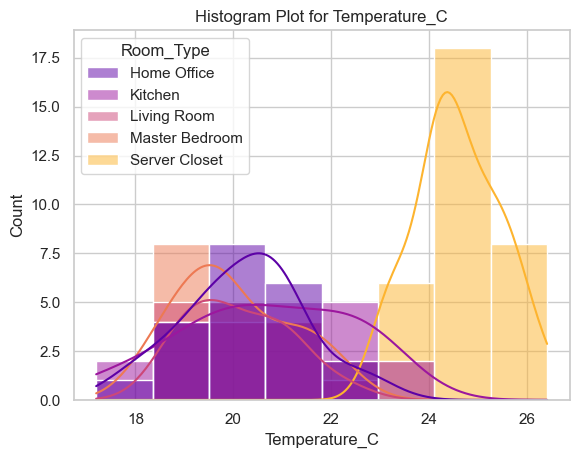

In [121]:
sns.histplot(
    x = 'Temperature_C', 
    kde=True,
    data=df,
    hue='Room_Type',
    palette='plasma'
    
)
sns.set_theme(style='whitegrid')
plt.title('Histogram Plot for Temperature_C')

Question 10
Explore multi-variable trends and operational dependencies:

Construct a scatter plot using Matplotlib or Seaborn plotting Temperature_C on the X-axis against Power_Consumption_kWh on the Y-axis.
Dynamically color-code individual data points using the hue variable parameter mapped to Device_Status to evaluate if offline units correspond to low sensor footprints.

Text(0.5, 1.0, 'Scatter plot')

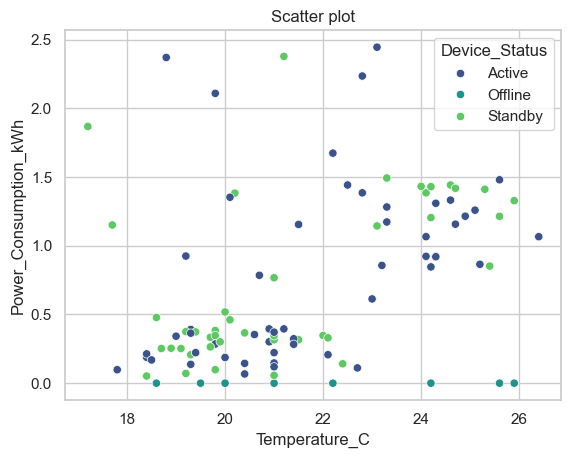

In [124]:
sns.scatterplot(
    data= df,
    x = 'Temperature_C',
    y = 'Power_Consumption_kWh', 

    hue='Device_Status',
    palette='viridis'
)
plt.title('Scatter plot')